In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer as knn

In [13]:
df = pd.read_csv(r'Data\feature_engineering.csv', sep='🔥')

C:\Users\mohammad.karimi\AppData\Local\Temp\ipykernel_20152\415468724.py:1: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char long, and the 'c' engine does not support such separators; you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(r'Data\feature_engineering.csv', sep='🔥')


In [14]:
df

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model
0,Mumbai,2010,72000,CNG,Manual,First,26.60,998,58.16,5,1.75,Maruti,Wagon R LXI CNG
1,Pune,2015,41000,Diesel,Manual,First,19.67,1582,126.20,5,12.50,Hyundai,Creta 1.6 CRDi SX Option
2,Chennai,2011,46000,Petrol,Manual,First,18.20,1199,88.70,5,4.50,Honda,Jazz V
3,Chennai,2012,87000,Diesel,Manual,First,20.77,1248,88.76,7,6.00,Maruti,Ertiga VDI
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968,140.80,5,17.74,Audi,A4 New 2.0 TDI Multitronic
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5970,Delhi,2014,27365,Diesel,Manual,First,28.40,1248,74.00,5,4.75,Maruti,Swift VDI
5971,Jaipur,2015,100000,Diesel,Manual,First,24.40,1120,71.00,5,4.00,Hyundai,Xcent 1.1 CRDi S
5972,Jaipur,2012,55000,Diesel,Manual,Second,14.00,2498,112.00,8,2.90,Mahindra,Xylo D4 BSIV
5973,Kolkata,2013,46000,Petrol,Manual,First,18.90,998,67.10,5,2.65,Maruti,Wagon R VXI


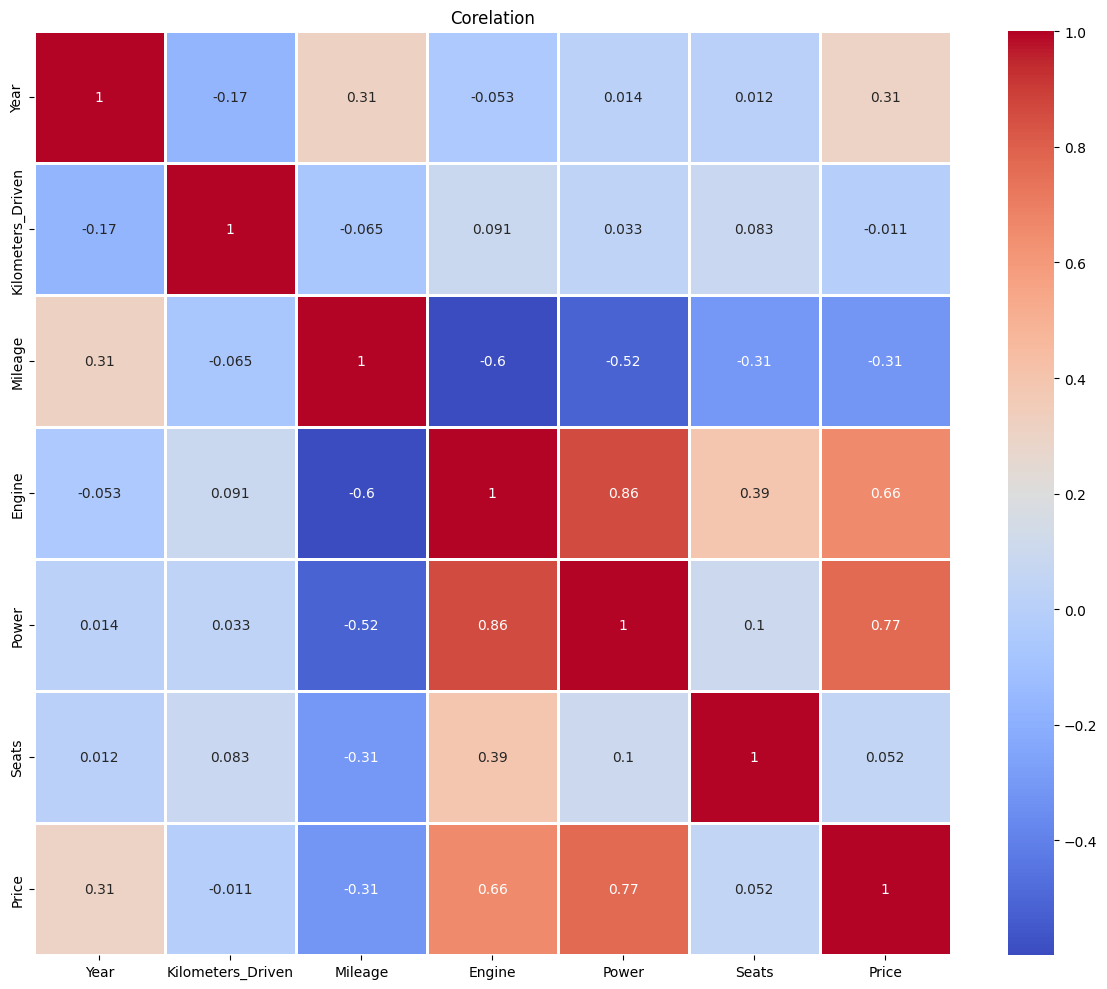

In [15]:
# dr = df.drop(columns=['Model'])
# dr = df.apply(lambda x : x.factorize()[0]).corr()
cor = df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(cor , 
            annot=True,
            cmap='coolwarm',
            linewidths=1,
            # cbar_kws={'shrink': 0.8}
            )
plt.title('Corelation')
plt.tight_layout()
plt.show()

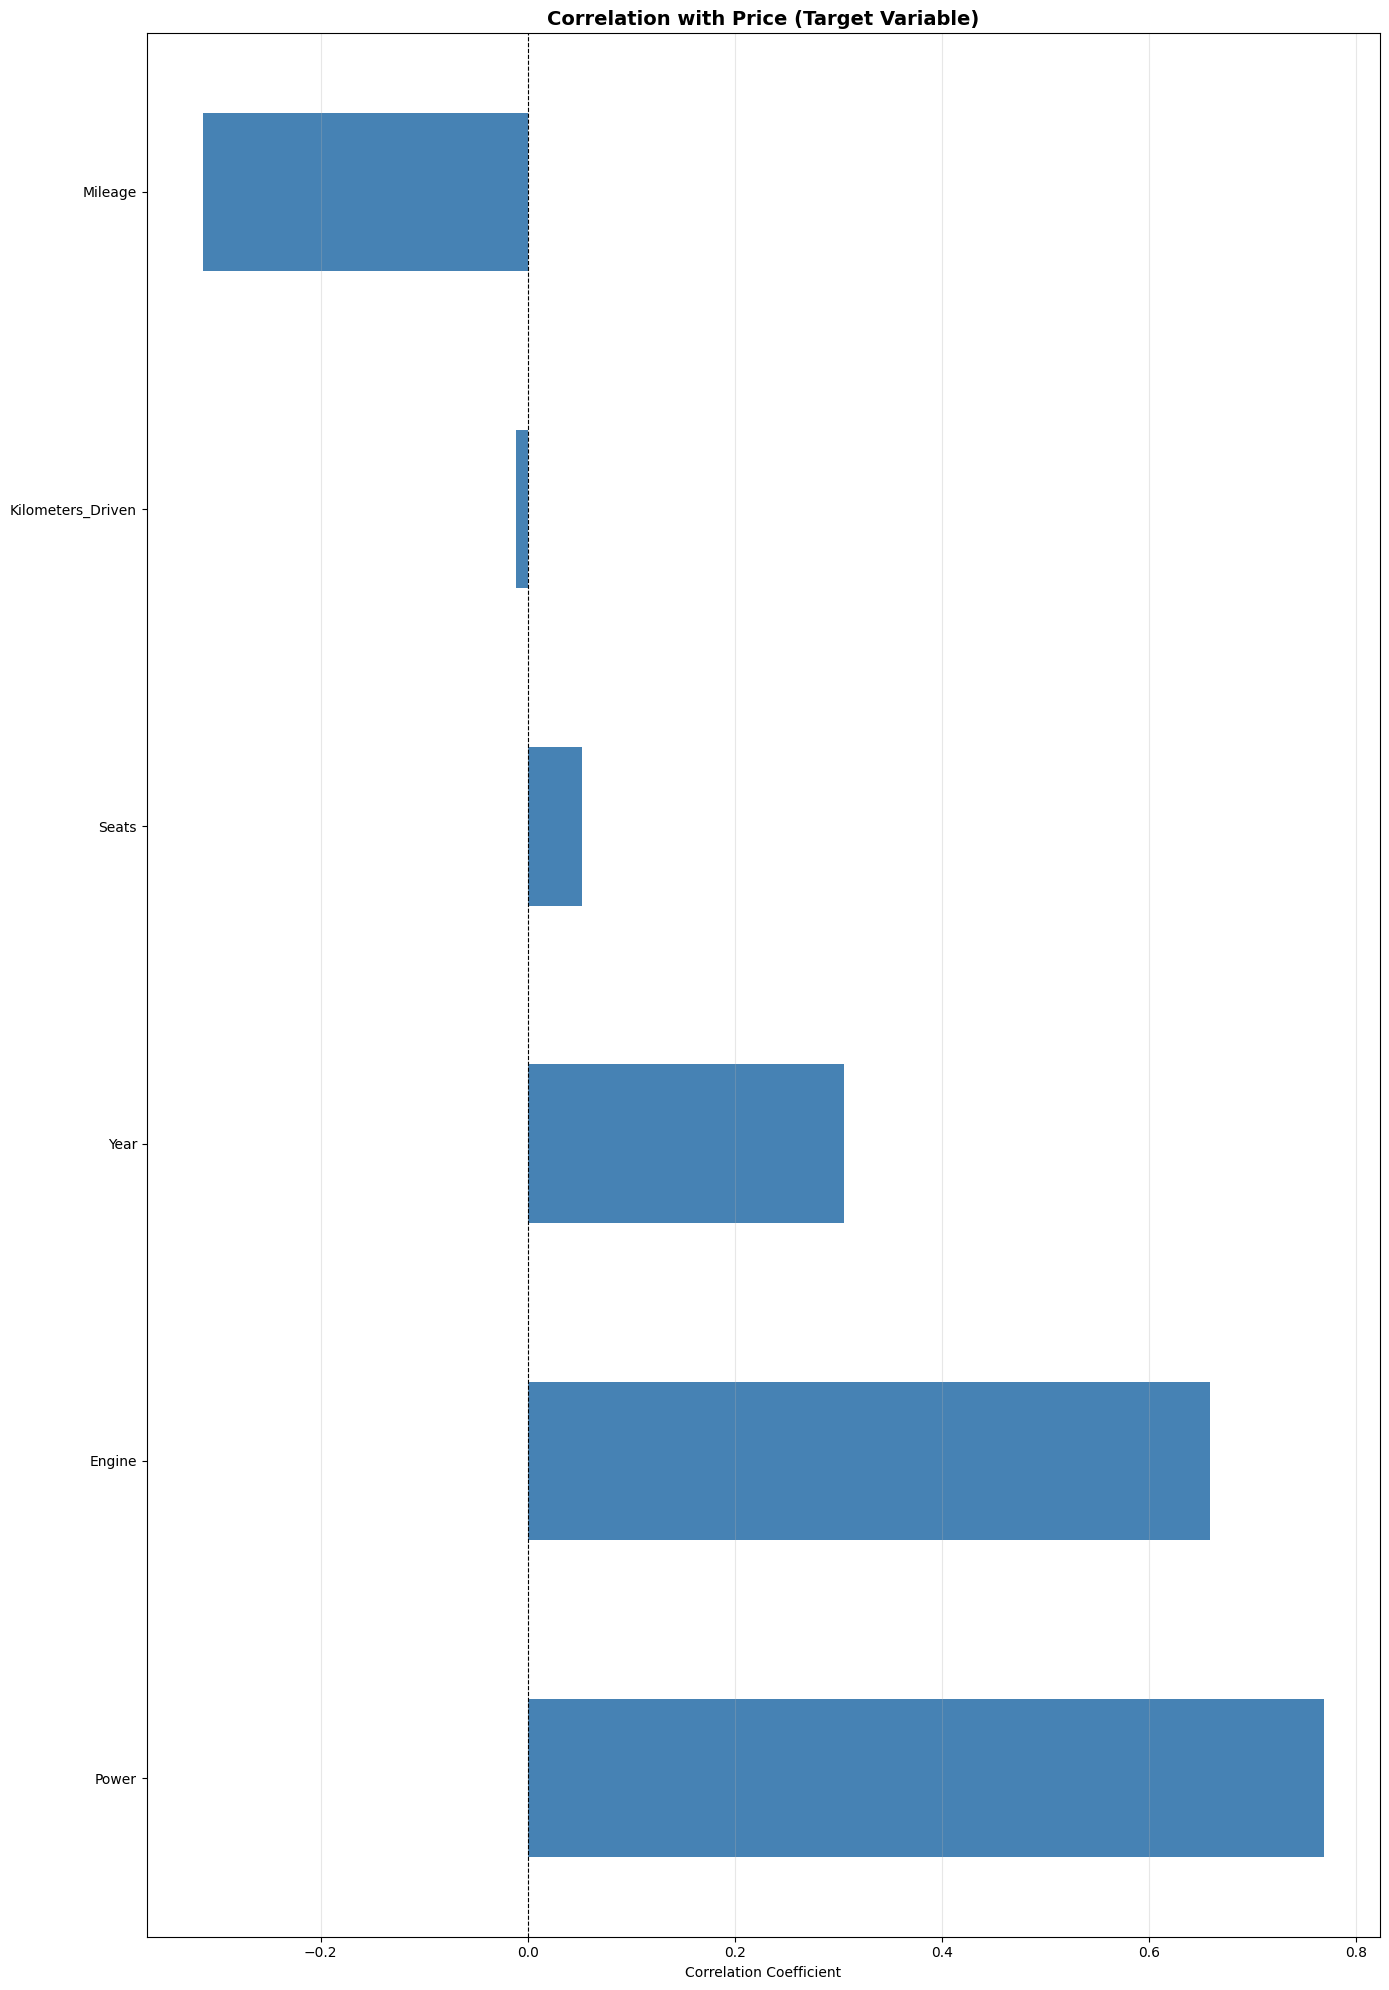

In [16]:
target_corr = cor['Price'].sort_values(ascending=False)

# Visualize
plt.figure(figsize=(14, 20))
target_corr[target_corr.index != 'Price'].plot(kind='barh', color='steelblue')
plt.title('Correlation with Price (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

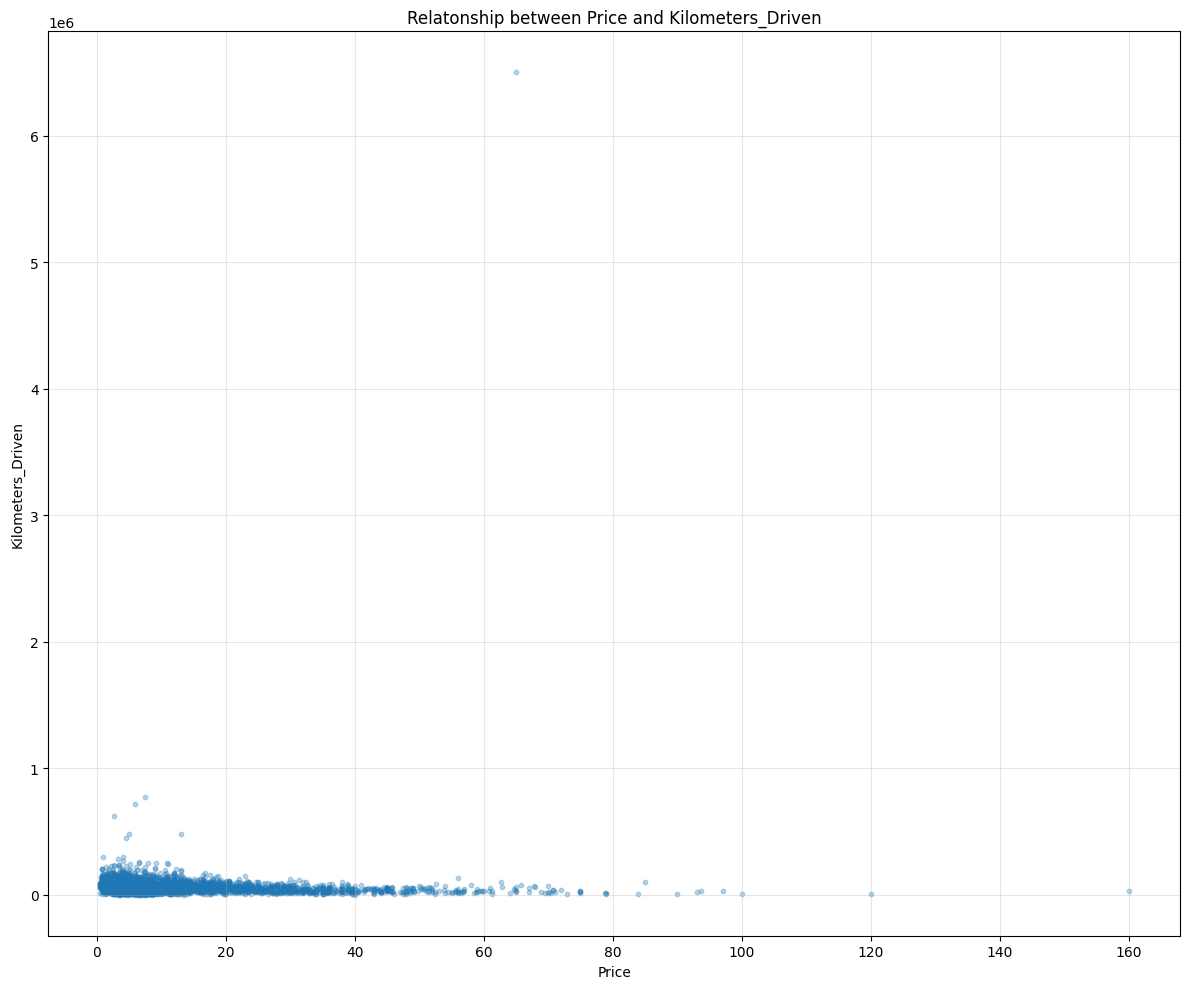

Correlation between Price and Kilometers_Driven: -0.01126330200449798


In [17]:
plt.figure(figsize=(12,10))
plt.scatter(df['Price'], df['Kilometers_Driven'], alpha=0.3, s=10)
plt.title('Relatonship between Price and Kilometers_Driven')
plt.xlabel('Price')
plt.ylabel('Kilometers_Driven')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
correlation = df['Price'].corr(df['Kilometers_Driven'])
print(f"Correlation between Price and Kilometers_Driven: {correlation}")

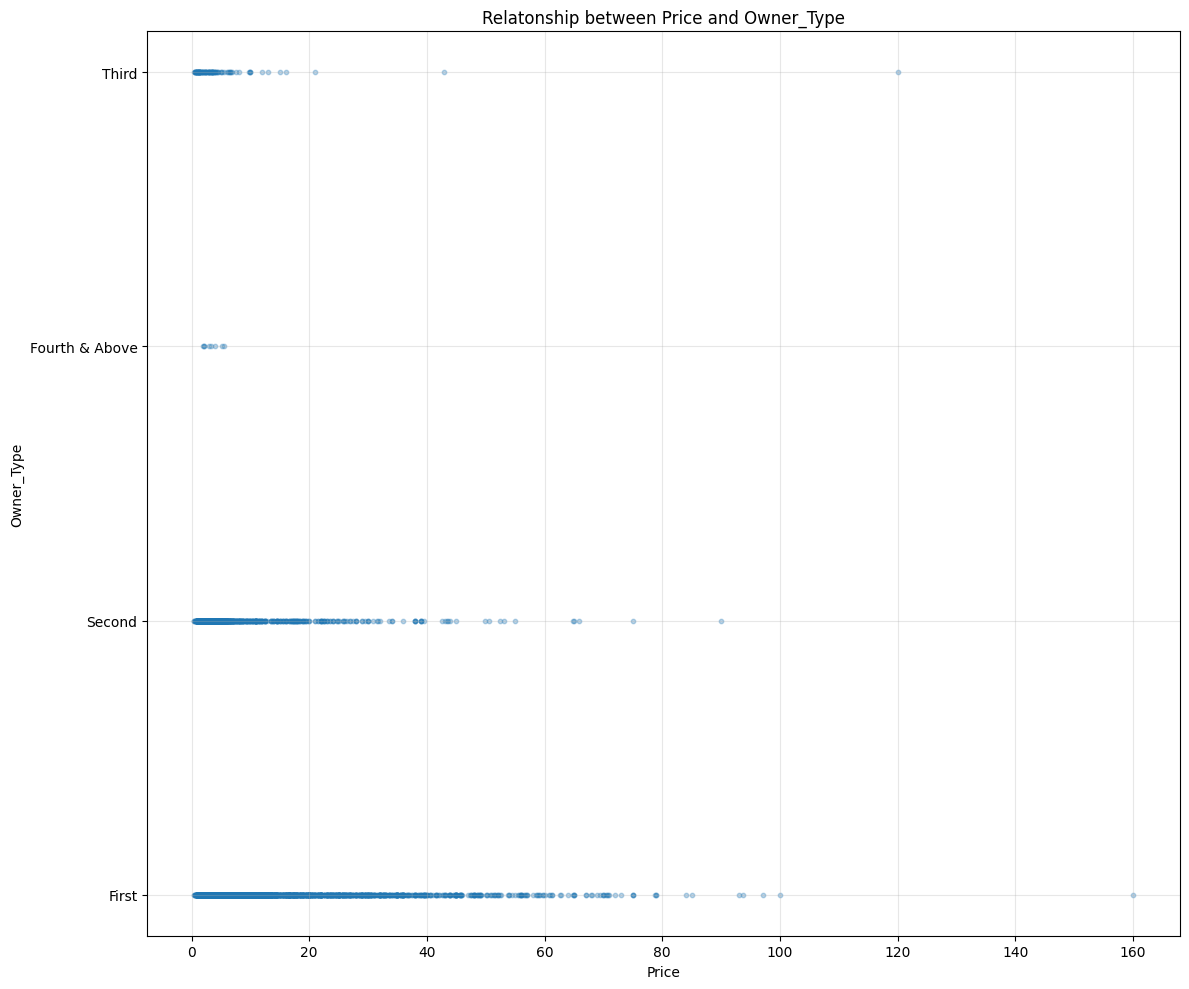

ValueError: could not convert string to float: 'First'

In [18]:
plt.figure(figsize=(12,10))
plt.scatter(df['Price'], df['Owner_Type'], alpha=0.3, s=10)
plt.title('Relatonship between Price and Owner_Type')
plt.xlabel('Price')
plt.ylabel('Owner_Type')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
correlation = df['Price'].corr(df['Owner_Type'])
print(f"Correlation between Price and Owner_Type: {correlation}")

In [ ]:
# df=pd.get_dummies(df, columns=["Location", "Fuel_Type","Transmission","Owner_Type","Brand"], dtype=(int))

In [ ]:
df.head()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price,Model,Location_Ahmedabad,Location_Bangalore,...,Brand_Mitsubishi,Brand_Nissan,Brand_Porsche,Brand_Renault,Brand_Skoda,Brand_Smart,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Brand_Volvo
0,2010,72000,26.60,998,58.16,5,1.75,Wagon R LXI CNG,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2015,41000,19.67,1582,126.20,5,12.50,Creta 1.6 CRDi SX Option,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2011,46000,18.20,1199,88.70,5,4.50,Jazz V,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2012,87000,20.77,1248,88.76,7,6.00,Ertiga VDI,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2013,40670,15.20,1968,140.80,5,17.74,A4 New 2.0 TDI Multitronic,0,0,...,0,0,0,0,0,0,0,0,0,0


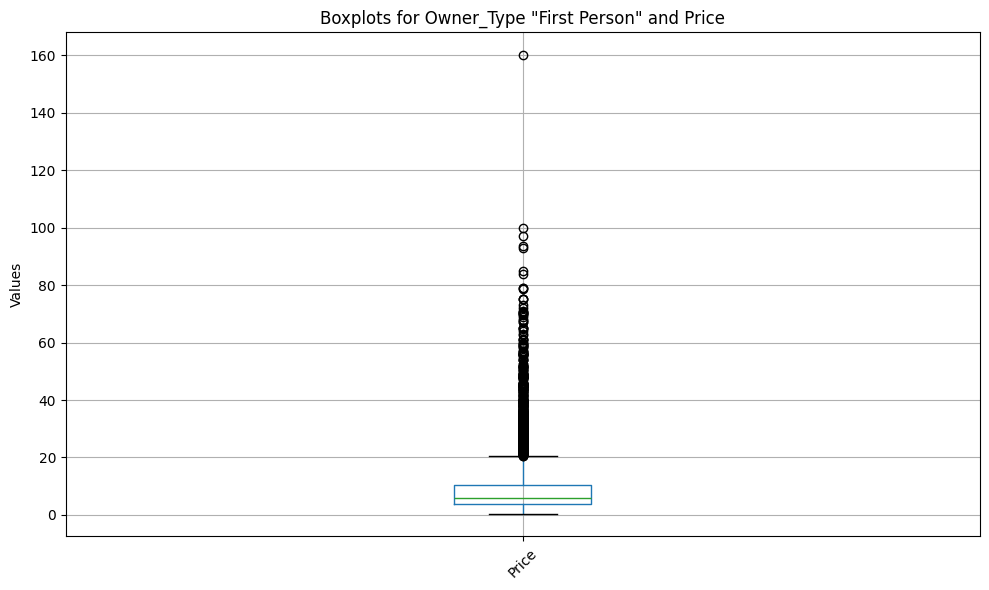

In [19]:
first=df[df['Owner_Type']=='First']
features = ['Price']

plt.figure(figsize=(10, 6))
first[features].boxplot()
plt.xticks(rotation=45)
plt.title('Boxplots for Owner_Type "First Person" and Price')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

In [20]:
Q1_roomsf = first['Price'].quantile(0.25)
Q3_roomsf = first['Price'].quantile(0.75)
IQR_roomsf = Q3_roomsf - Q1_roomsf

lower_rooms = Q1_roomsf - 1.5 * IQR_roomsf
upper_rooms = Q3_roomsf + 1.5 * IQR_roomsf

outliers_rooms = first[(first['Price'] < lower_rooms) | (first['Price'] > upper_rooms)]
print(len(outliers_rooms))
print(len(first))

590
4903


In [21]:
# df=df[df['Owner_Type']=='First']
print(f"Original data: {len(first)} rows")

# Cap AveRooms

upper = Q3_roomsf + 1.5 * IQR_roomsf

fir= df['Price'] = df[df['Owner_Type']=='First'].clip(upper=upper)
print(f"AveRooms capped at: {upper:.2f}")

Original data: 4903 rows


TypeError: '<=' not supported between instances of 'str' and 'float'

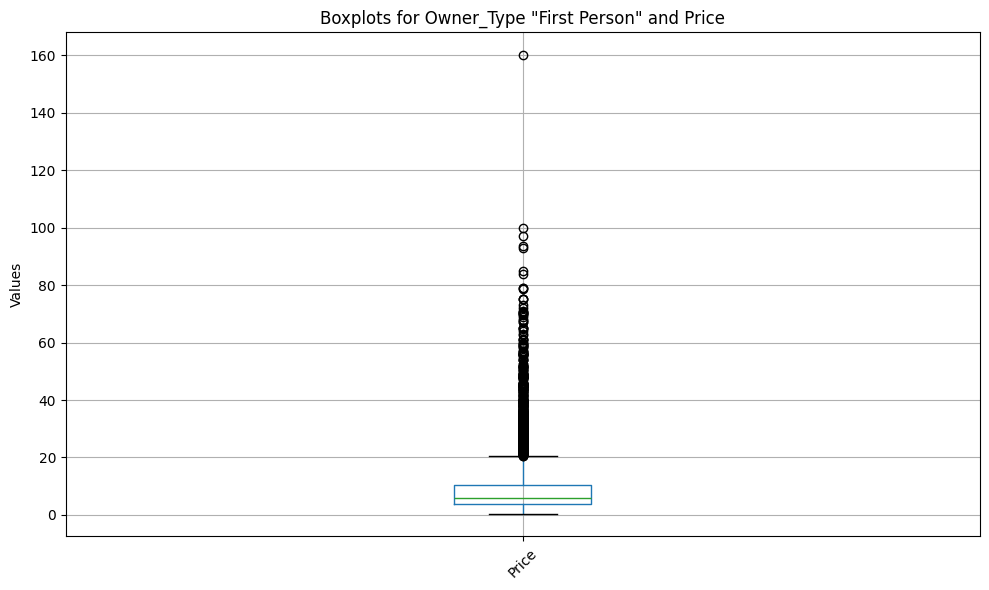

In [22]:
features = ['Price']

plt.figure(figsize=(10, 6))
first[features].boxplot()
plt.xticks(rotation=45)
plt.title('Boxplots for Owner_Type "First Person" and Price')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

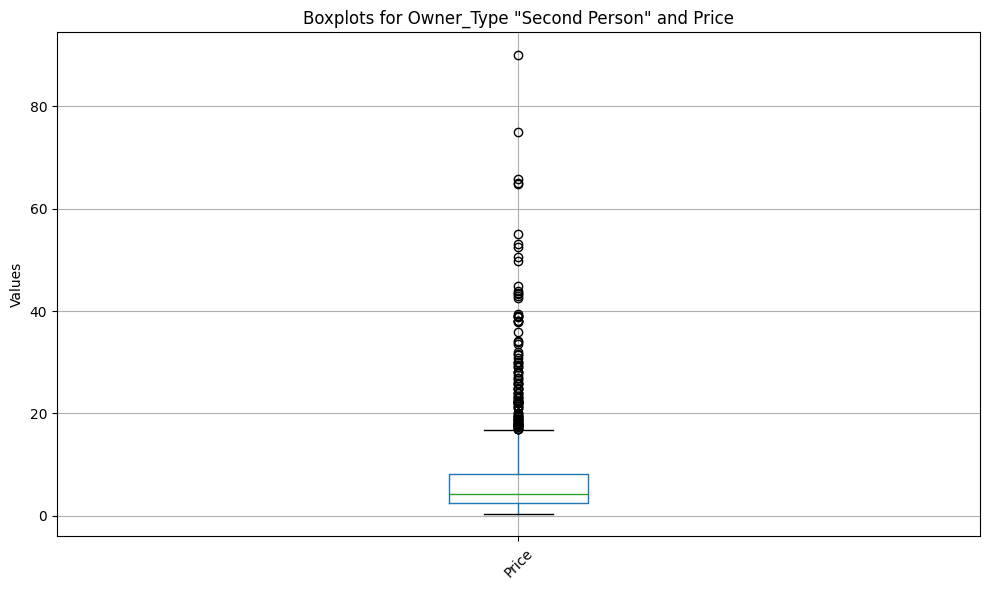

In [23]:
second=df[df['Owner_Type']=='Second']
features = ['Price']

plt.figure(figsize=(10, 6))
second[features].boxplot()
plt.xticks(rotation=45)
plt.title('Boxplots for Owner_Type "Second Person" and Price')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

In [24]:
Q1_rooms = second['Price'].quantile(0.25)
Q3_rooms = second['Price'].quantile(0.75)
IQR_rooms = Q3_rooms - Q1_rooms

lower_rooms = Q1_rooms - 1.5 * IQR_rooms
upper_rooms = Q3_rooms + 1.5 * IQR_rooms

outliers_rooms = second[(second['Price'] < lower_rooms) | (second['Price'] > upper_rooms)]
print(len(outliers_rooms))
print(len(second))

111
953


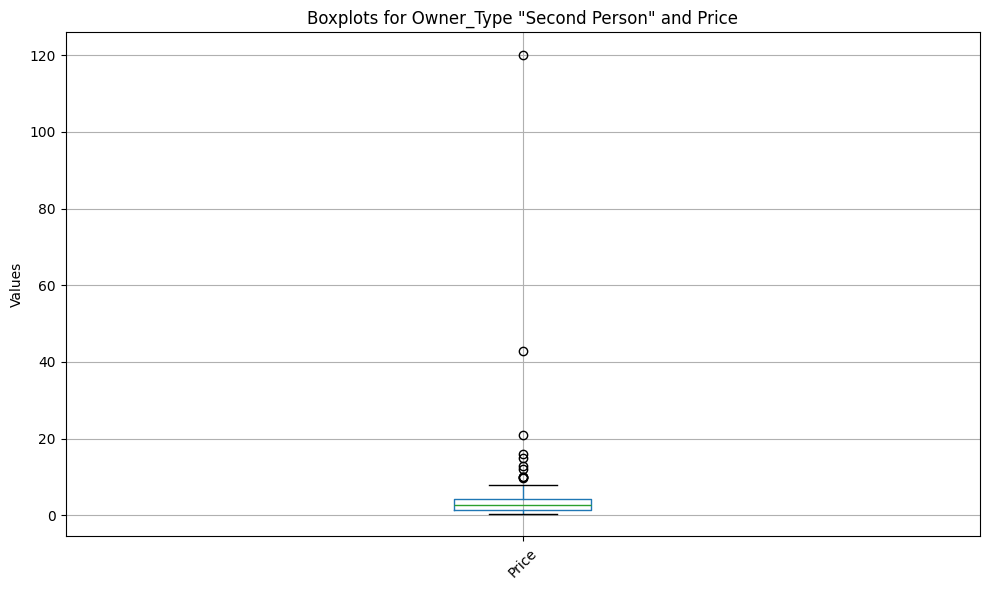

NameError: name 'po' is not defined

In [25]:
Third=df[df['Owner_Type']=='Third']
features = ['Price']

plt.figure(figsize=(10, 6))
Third[features].boxplot()
plt.xticks(rotation=45)
plt.title('Boxplots for Owner_Type "Second Person" and Price')
plt.ylabel('Values')
plt.tight_layout()
plt.show()
print(len(po))

In [26]:
Q1_rooms = Third['Price'].quantile(0.25)
Q3_rooms = Third['Price'].quantile(0.75)
IQR_rooms = Q3_rooms - Q1_rooms

lower_rooms = Q1_rooms - 1.5 * IQR_rooms
upper_rooms = Q3_rooms + 1.5 * IQR_rooms

outliers_rooms = Third[(Third['Price'] < lower_rooms) | (Third['Price'] > upper_rooms)]
print(len(outliers_rooms))
print(len(Third))

11
111


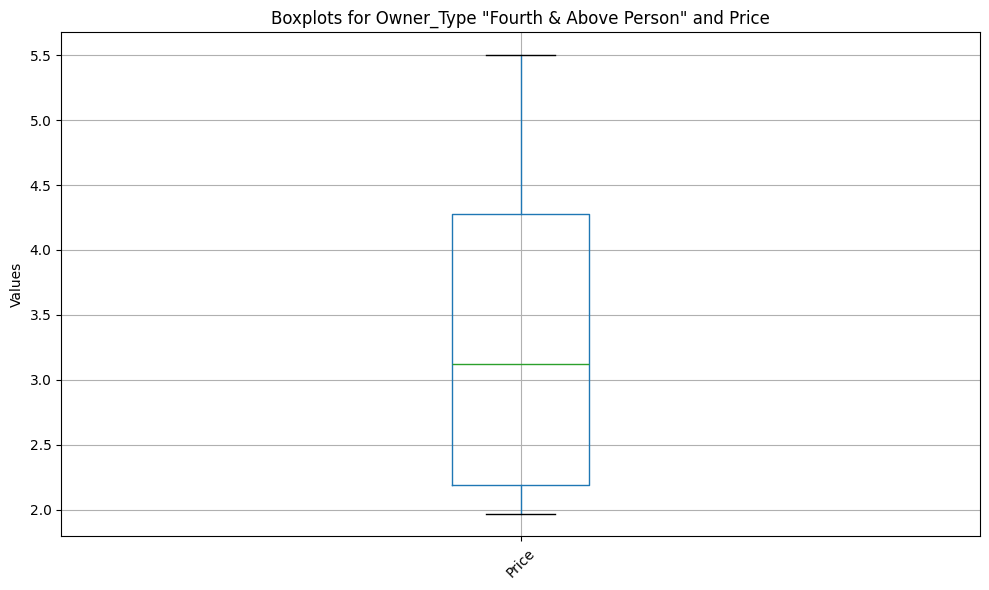

In [27]:
Fourth=df[df['Owner_Type']=='Fourth & Above']
features = ['Price']

plt.figure(figsize=(10, 6))
Fourth[features].boxplot()
plt.xticks(rotation=45)
plt.title('Boxplots for Owner_Type "Fourth & Above Person" and Price')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

In [28]:
Q1_rooms = Fourth['Price'].quantile(0.25)
Q3_rooms = Fourth['Price'].quantile(0.75)
IQR_rooms = Q3_rooms - Q1_rooms

lower_rooms = Q1_rooms - 1.5 * IQR_rooms
upper_rooms = Q3_rooms + 1.5 * IQR_rooms

outliers_rooms = Fourth[(Fourth['Price'] < lower_rooms) | (Fourth['Price'] > upper_rooms)]
print(len(outliers_rooms))
print(len(Fourth))

0
8


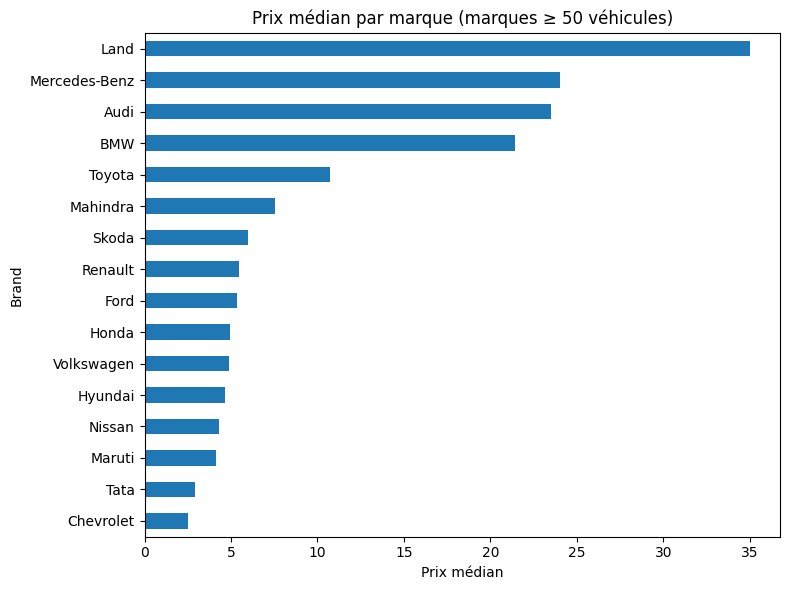

In [29]:
brand_counts = df["Brand"].value_counts()
valid_brands = brand_counts[brand_counts >= 50].index
 
price_by_brand_filtered = (
    df[df["Brand"].isin(valid_brands)]
    .groupby("Brand")["Price"]
    .median()
    .sort_values()
)
 
import matplotlib.pyplot as plt
 
plt.figure(figsize=(8,6))
price_by_brand_filtered.plot(kind="barh")
plt.xlabel("Prix médian")
plt.title("Prix médian par marque (marques ≥ 50 véhicules)")
plt.tight_layout()
plt.show()

TypeError: no numeric data to plot

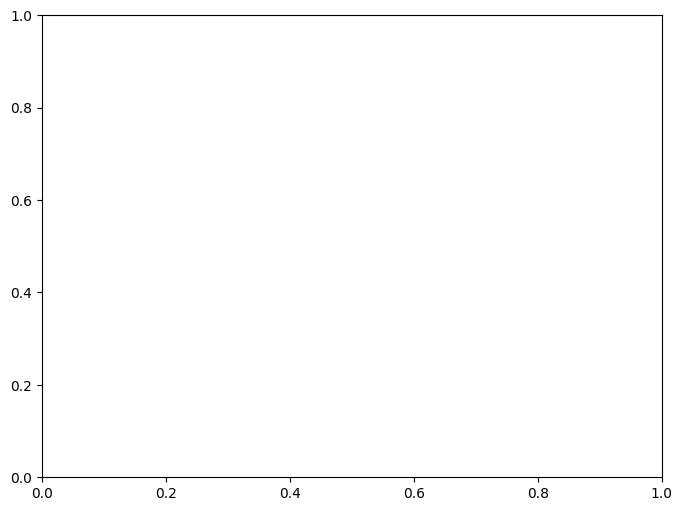

In [ ]:
price_brand_trans = (
    df
    .groupby(["Brand", "Transmission"])["Price"]
    .median()
    .unstack()
    .sort_values(by="Automatic", ascending=False)
)
 
price_brand_trans.head(10)

Transmission,Automatic,Manual
Brand,,
Lamborghini,120.000,NaN
Bentley,59.000,NaN
Porsche,48.220,40.000
Land,35.000,NaN
Jaguar,31.900,NaN
Ford,25.000,4.545
Mercedes-Benz,24.570,14.375
Mini,23.800,35.000
Audi,23.500,NaN


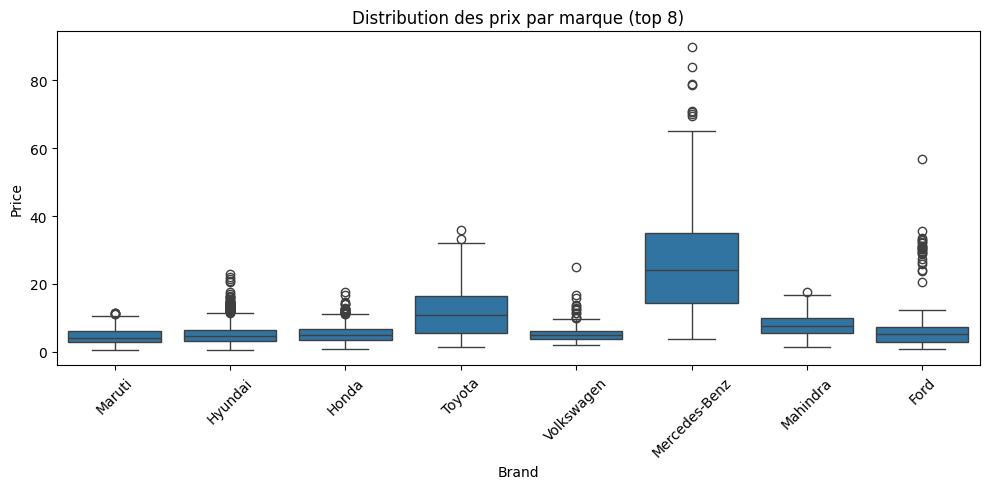

In [ ]:
top_brands = brand_counts.head(8).index
 
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df[df["Brand"].isin(top_brands)],
    x="Brand",
    y="Price"
)
plt.title("Distribution des prix par marque (top 8)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

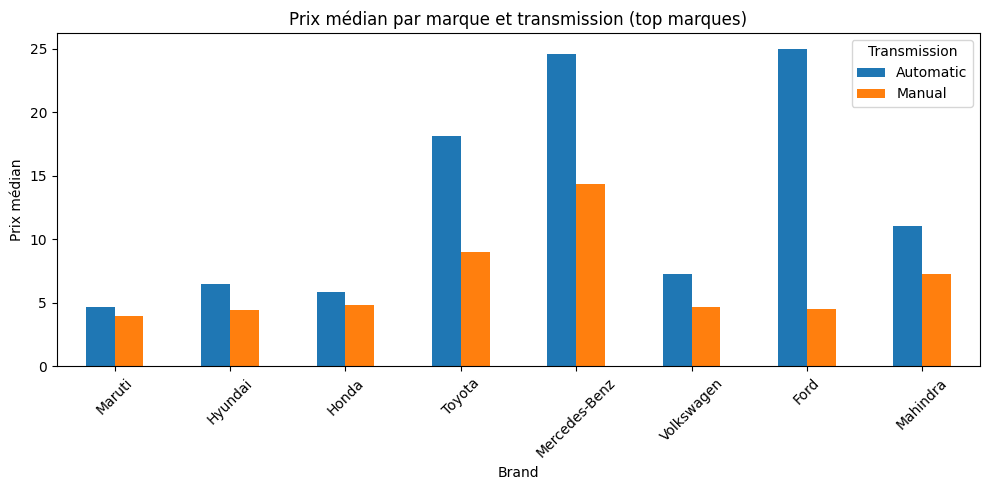

In [ ]:
 
top_brands = df["Brand"].value_counts().head(8).index
 
price_brand_trans.loc[top_brands].plot(
    kind="bar",
    figsize=(10,5)
)
plt.ylabel("Prix médian")
plt.title("Prix médian par marque et transmission (top marques)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
data=pd.read_csv(r'Data\feature_engineering.csv', sep='🔥')


C:\Users\mohammad.karimi\AppData\Local\Temp\ipykernel_9188\2064870261.py:1: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char long, and the 'c' engine does not support such separators; you can avoid this warning by specifying engine='python'.
  data=pd.read_csv(r'Data\feature_engineering.csv', sep='🔥')


In [ ]:
data.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,5975.000000,5.975000e+03,5975.000000,5975.000000,5975.000000,5975.000000,5975.000000
mean,2013.386778,5.867431e+04,18.179408,1621.606695,113.276894,5.278828,9.501647
std,3.247238,9.155851e+04,4.521801,601.036987,53.415373,0.808959,11.205736
min,1998.000000,1.710000e+02,0.000000,624.000000,34.200000,0.000000,0.440000
25%,2012.000000,3.390800e+04,15.200000,1198.000000,77.000000,5.000000,3.500000
50%,2014.000000,5.300000e+04,18.160000,1493.000000,98.600000,5.000000,5.650000
75%,2016.000000,7.300000e+04,21.100000,1984.000000,138.100000,5.000000,9.950000
max,2019.000000,6.500000e+06,33.540000,5998.000000,560.000000,10.000000,160.000000


In [ ]:
data.head()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model
0,Mumbai,2010,72000,CNG,Manual,First,26.60,998,58.16,5,1.75,Maruti,Wagon R LXI CNG
1,Pune,2015,41000,Diesel,Manual,First,19.67,1582,126.20,5,12.50,Hyundai,Creta 1.6 CRDi SX Option
2,Chennai,2011,46000,Petrol,Manual,First,18.20,1199,88.70,5,4.50,Honda,Jazz V
3,Chennai,2012,87000,Diesel,Manual,First,20.77,1248,88.76,7,6.00,Maruti,Ertiga VDI
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968,140.80,5,17.74,Audi,A4 New 2.0 TDI Multitronic


In [ ]:
import time 

In [ ]:

data["car_age"]= time.localtime().tm_year-data["Year"]

data.head()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model,car_age
0,Mumbai,2010,72000,CNG,Manual,First,26.60,998,58.16,5,1.75,Maruti,Wagon R LXI CNG,16
1,Pune,2015,41000,Diesel,Manual,First,19.67,1582,126.20,5,12.50,Hyundai,Creta 1.6 CRDi SX Option,11
2,Chennai,2011,46000,Petrol,Manual,First,18.20,1199,88.70,5,4.50,Honda,Jazz V,15
3,Chennai,2012,87000,Diesel,Manual,First,20.77,1248,88.76,7,6.00,Maruti,Ertiga VDI,14
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968,140.80,5,17.74,Audi,A4 New 2.0 TDI Multitronic,13


In [ ]:
data["km/age"]=data["Kilometers_Driven"]/data["car_age"]

data.head()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model,car_age,km/age
0,Mumbai,2010,72000,CNG,Manual,First,26.60,998,58.16,5,1.75,Maruti,Wagon R LXI CNG,16,4500.000000
1,Pune,2015,41000,Diesel,Manual,First,19.67,1582,126.20,5,12.50,Hyundai,Creta 1.6 CRDi SX Option,11,3727.272727
2,Chennai,2011,46000,Petrol,Manual,First,18.20,1199,88.70,5,4.50,Honda,Jazz V,15,3066.666667
3,Chennai,2012,87000,Diesel,Manual,First,20.77,1248,88.76,7,6.00,Maruti,Ertiga VDI,14,6214.285714
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968,140.80,5,17.74,Audi,A4 New 2.0 TDI Multitronic,13,3128.461538


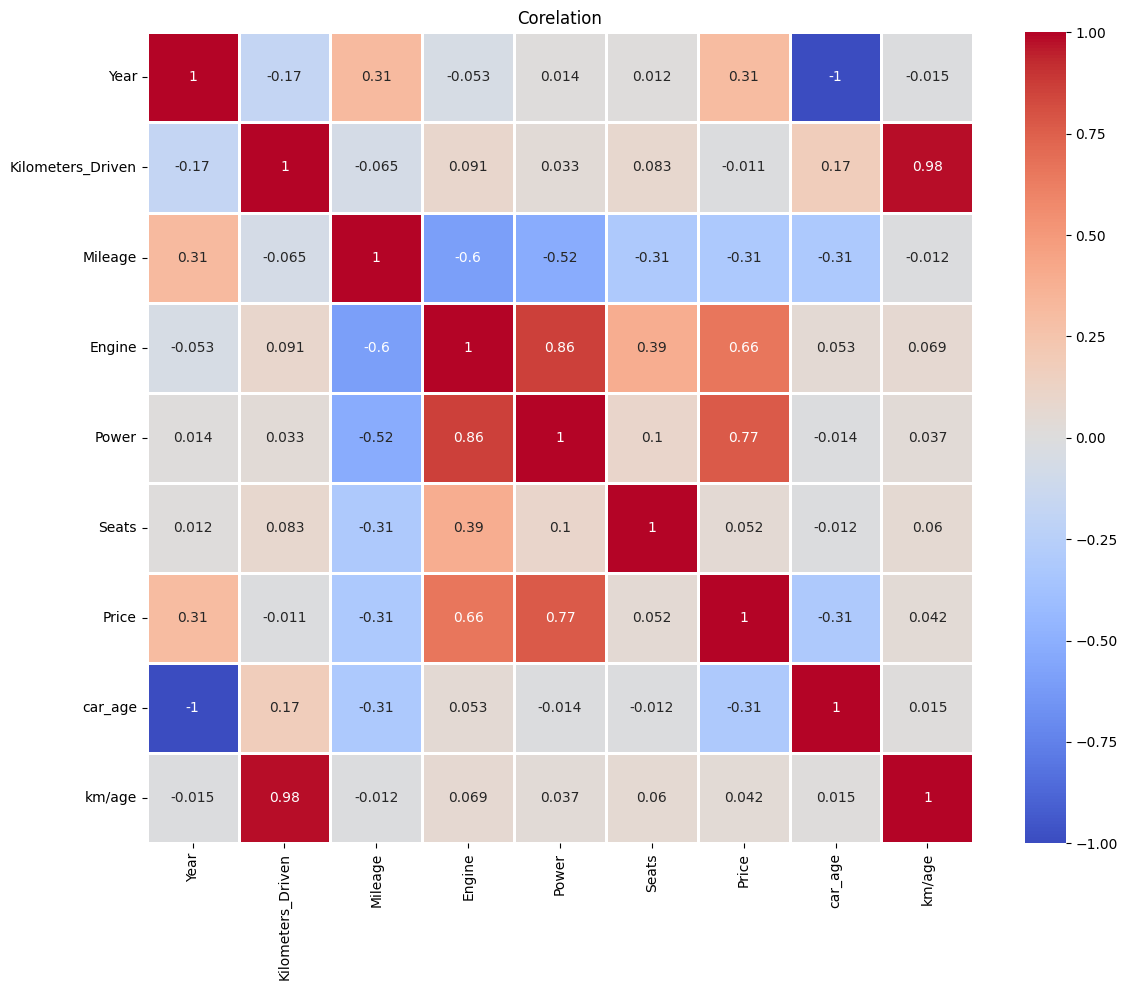

In [ ]:
dr = data.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(dr , 
            annot=True,
            cmap='coolwarm',
            linewidths=1,
            # cbar_kws={'shrink': 0.8}
            )
plt.title('Corelation')
plt.tight_layout()
plt.show()

In [ ]:
data["Fuel_Type"].unique()

<StringArray>
['CNG', 'Diesel', 'Petrol', 'LPG']
Length: 4, dtype: str

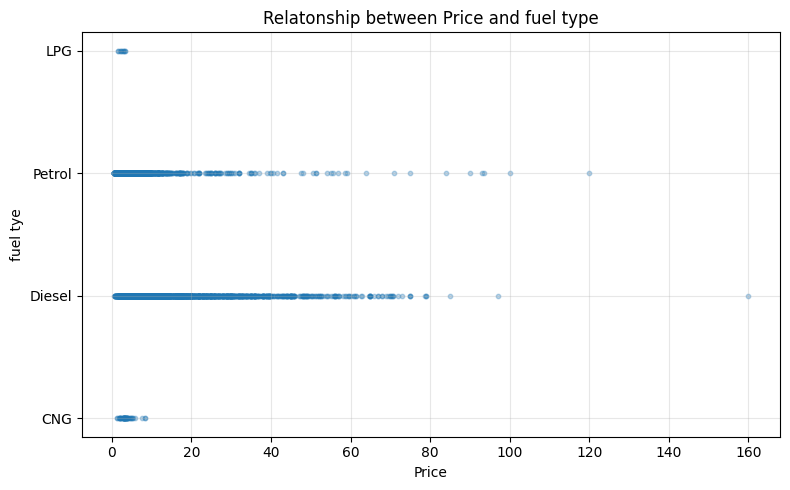

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(data['Price'], data['Fuel_Type'], alpha=0.3, s=10)
plt.title('Relatonship between Price and fuel type')
plt.xlabel('Price')
plt.ylabel('fuel tye')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5975 entries, 0 to 5974
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           5975 non-null   str    
 1   Year               5975 non-null   int64  
 2   Kilometers_Driven  5975 non-null   int64  
 3   Fuel_Type          5975 non-null   str    
 4   Transmission       5975 non-null   str    
 5   Owner_Type         5975 non-null   str    
 6   Mileage            5975 non-null   float64
 7   Engine             5975 non-null   int64  
 8   Power              5975 non-null   float64
 9   Seats              5975 non-null   int64  
 10  Price              5975 non-null   float64
 11  Brand              5975 non-null   str    
 12  Model              5975 non-null   str    
 13  car_age            5975 non-null   int64  
 14  km/age             5975 non-null   float64
dtypes: float64(4), int64(5), str(6)
memory usage: 700.3 KB


In [ ]:
data=data.rename(columns={"Mileage" : "Consumation"})

In [ ]:
data.to_csv("data_to_train.csv",index=False)